In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import math
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from sklearn.preprocessing import MinMaxScaler

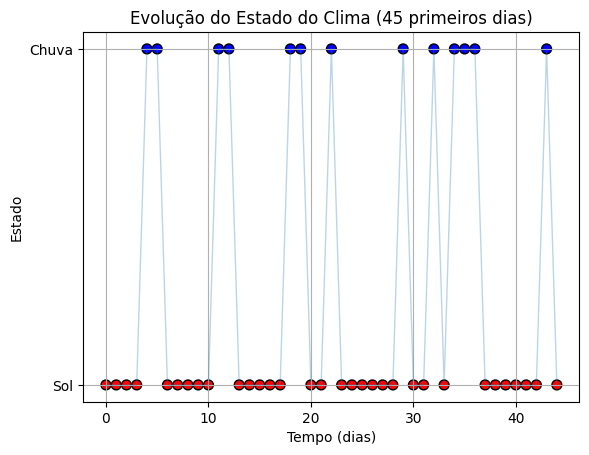

In [9]:
dados = pd.read_csv('previsaoClima.csv')
mapa = {'Sol': 0, 'Chuva': 1}

dados['estado_num'] = dados['estado'].map(mapa)
dadosPlot = dados.iloc[:45]


x = range(len(dadosPlot))
y = dadosPlot['estado_num']

plt.figure()

# Optional: thin line (no vertical jumps)
plt.plot(x, y, linewidth=1, alpha=0.3)

# Bigger, clearer dots with edge
plt.scatter(
    x, y,
    c=['red' if v == 0 else 'blue' for v in y],
    s=50,              # bigger dots
     edgecolors='black'
   
)

plt.yticks([0, 1], ['Sol', 'Chuva'])
plt.xlabel('Tempo (dias)')
plt.ylabel('Estado')
plt.title('Evolução do Estado do Clima (45 primeiros dias)')

plt.grid(True)
plt.show()

In [4]:
diasChuva = 0
diasSol = 0

distribuicao_meses = []

for index, dado in dados['estado_num'].items():
    if (dado == 0):
        diasSol += 1
    else:
        diasChuva +=1

    if(index % 30 == 0 and index != 0):
        distribuicao_meses.append({"Dias de Sol": diasSol, "Dias de Chuva": diasChuva})
        diasChuva = 0
        diasSol = 0

for index, mes in enumerate(distribuicao_meses):
    print(f"Mês  {index + 1}\n  {mes}")

Mês  1
  {'Dias de Sol': 23, 'Dias de Chuva': 8}
Mês  2
  {'Dias de Sol': 20, 'Dias de Chuva': 10}
Mês  3
  {'Dias de Sol': 23, 'Dias de Chuva': 7}
Mês  4
  {'Dias de Sol': 23, 'Dias de Chuva': 7}
Mês  5
  {'Dias de Sol': 17, 'Dias de Chuva': 13}
Mês  6
  {'Dias de Sol': 22, 'Dias de Chuva': 8}
Mês  7
  {'Dias de Sol': 15, 'Dias de Chuva': 15}
Mês  8
  {'Dias de Sol': 21, 'Dias de Chuva': 9}
Mês  9
  {'Dias de Sol': 21, 'Dias de Chuva': 9}
Mês  10
  {'Dias de Sol': 20, 'Dias de Chuva': 10}
Mês  11
  {'Dias de Sol': 21, 'Dias de Chuva': 9}
Mês  12
  {'Dias de Sol': 23, 'Dias de Chuva': 7}


In [11]:
diasSol = []
diasChuva = []

for mes in distribuicao_meses:
    diasSol.append(mes["Dias de Sol"])
    diasChuva.append(mes["Dias de Chuva"])

diasSol = np.array(diasSol)
diasChuva = np.array(diasChuva)

print("Estatísticas dia Sol")
pd.Series(diasSol).describe()


Estatísticas dia Sol


count    12.000000
mean     20.750000
std       2.527126
min      15.000000
25%      20.000000
50%      21.000000
75%      23.000000
max      23.000000
dtype: float64

In [12]:
print("\n Estatísticas dia Chuva")
pd.Series(diasChuva).describe()


 Estatísticas dia Chuva


count    12.000000
mean      9.333333
std       2.461830
min       7.000000
25%       7.750000
50%       9.000000
75%      10.000000
max      15.000000
dtype: float64

In [15]:
train = dados['estado_num'][0:274].values.reshape(-1, 1)
test = dados['estado_num'][274:366].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))

train_scale = scaler.fit_transform(train)
test_scale = scaler.transform(test)

In [13]:
def prepare_data(data, lags=1):
  x,y = [],[]
  for row in range(len(data)-lags-1):
    a = data[row:(row+lags)]
    x.append(a)
    y.append(data[row+lags])
  return np.array(x), np.array(y)

In [16]:
lags = 1
x_train, y_train = prepare_data(train_scale, lags)
x_test, y_test = prepare_data(test_scale, lags)
y_true = y_test

In [17]:
np.shape(x_test)

(90, 1, 1)

In [26]:
md1 = Sequential()
md1.add(Dense(32, input_shape=(lags,), activation='relu'))
md1.add(Dense(16, input_shape=(lags,), activation='relu'))
md1.add(Dense(1, activation='linear'))
md1.compile(loss='mean_squared_error', optimizer='adam')
md1.fit(x_train, y_train, epochs=500, batch_size=2, verbose=2)

Epoch 1/500
136/136 - 1s - 6ms/step - loss: 0.2908
Epoch 2/500
136/136 - 0s - 1ms/step - loss: 0.2563
Epoch 3/500
136/136 - 0s - 1ms/step - loss: 0.2372
Epoch 4/500
136/136 - 0s - 1ms/step - loss: 0.2268
Epoch 5/500
136/136 - 0s - 1ms/step - loss: 0.2212
Epoch 6/500
136/136 - 0s - 1ms/step - loss: 0.2187
Epoch 7/500
136/136 - 0s - 1ms/step - loss: 0.2175
Epoch 8/500
136/136 - 0s - 1ms/step - loss: 0.2167
Epoch 9/500
136/136 - 0s - 1ms/step - loss: 0.2165
Epoch 10/500
136/136 - 0s - 1ms/step - loss: 0.2165
Epoch 11/500
136/136 - 0s - 1ms/step - loss: 0.2164
Epoch 12/500
136/136 - 0s - 1ms/step - loss: 0.2164
Epoch 13/500
136/136 - 0s - 1ms/step - loss: 0.2165
Epoch 14/500
136/136 - 0s - 1ms/step - loss: 0.2166
Epoch 15/500
136/136 - 0s - 1ms/step - loss: 0.2166
Epoch 16/500
136/136 - 0s - 1ms/step - loss: 0.2165
Epoch 17/500
136/136 - 0s - 1ms/step - loss: 0.2165
Epoch 18/500
136/136 - 0s - 1ms/step - loss: 0.2165
Epoch 19/500
136/136 - 0s - 1ms/step - loss: 0.2164
Epoch 20/500
136/136 

In [27]:
train_predict = md1.predict(x_train)
test_predict = md1.predict(x_test)

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train_original = scaler.inverse_transform(y_train)
y_test_original = scaler.inverse_transform(y_test)
x_test_original = scaler.inverse_transform(x_test.reshape(-1, 1))
x_train_original = scaler.inverse_transform(x_train.reshape(-1, 1))

y_true = scaler.inverse_transform(y_true)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


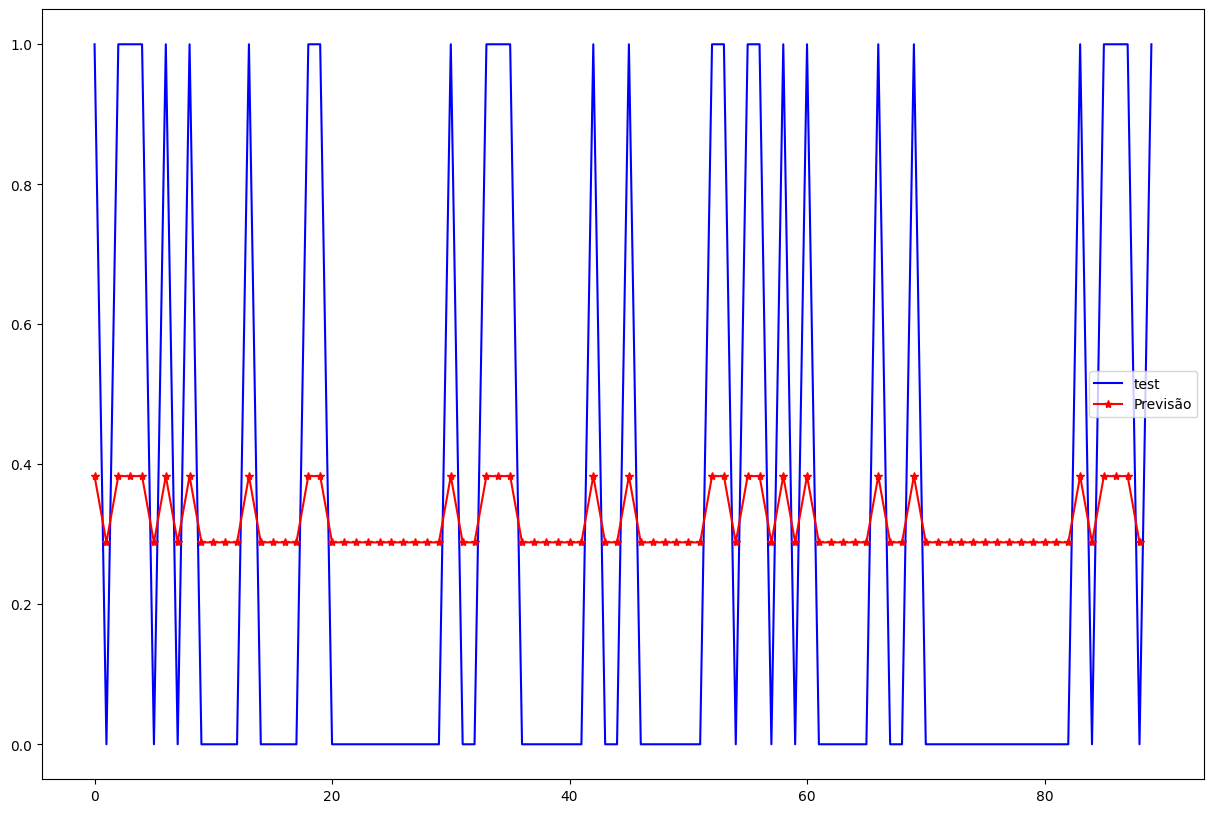

In [20]:
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 10
plt.plot(y_test_original, color= 'blue', label='test')
plt.plot(test_predict[1:], marker = "*", color='red', label='Previsão')
plt.legend()
plt.show()

In [28]:
train_score = md1.evaluate(x_train, y_train, verbose=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2162 


In [29]:
lossTrain =  0.2141
erroTrain = math.sqrt(lossTrain)*100

str(erroTrain) + " %"

'46.2709412050371 %'